---
title: "Heatmaps"
subtitle: "DS 2023 | Communicating with Data"
---

<img src="https://virginia.box.com/shared/static/k6qk3jrsmftvsurlzogfgm103e9icmwl.png"/>

## Overview

A **heatmap** displays a matrix of numbers as a grid of colored cells, where the color value in a cell is a function of the number value there.

Heatmaps show the relationship between **two grouping variables** and **a measurement variable** by using the visual channel of color to indicate intensity. 

> [!TIP]
>
> Think of a heatmap like a scatter plot for categorical data.
>
> In fact, we've seen how a scatter plot can be converted into a heatmap with the Matplotlib's `hexbin` function. 

## Use Cases

**Visualizing wide-form data**. Heatmaps can almost always be used to show the distribution of values in a wide table. As such, they are a good compliment to subplots generated from such tables. 

**Seeing structure in a large table at a glance.** The advantage of a heatmap is that it shows **two-dimensional patterns**: blocks, stripes and criss-crosses, and gaps jump out that you would never notice scanning raw numbers.

**Correlation and confusion matrices.** A square matrix of relationships between variables (or predicted-vs-actual class counts) is often  shown as a heatmap.

**Contingency matrices.** A heatmap can be used to show the pair-wise, co-ocurrence data. They are a good compliment to network diagrams of the same data.

## Creating a heatmap from scratch

Let's create a heatmap from scratch.

We'll use a dataset of passenger counts on airline flights grouped by year and month. 

This gives us a table of two grouping variables and a measurement one.

In [465]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

flight_data_src = "https://virginia.box.com/shared/static/c8i3oyp8koeviixg2f9os7f0bgy869lf.csv"
flight = pd.read_csv(flight_data_src)
flight.info()
flight.head()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Years       144 non-null    int64
 1   Months      144 non-null    str  
 2   Passengers  144 non-null    int64
dtypes: int64(2), str(1)
memory usage: 4.4 KB


,Years,Months,Passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


To ensure that the months display in the right order, we convert these into `Categorical` data type.

In [466]:
flight.Months.unique()

<ArrowStringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

In [467]:
flight['Months'] = pd.Categorical(flight['Months'], categories=flight.Months.unique(), ordered=True)

**First, we create a wide dataframe.**

In [468]:
flight_wide = flight.pivot(columns='Years', index='Months', values='Passengers')
flight_wide.head()

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472


**Then, we scale all the values to be in $[0,1]$.**

$$v_{scaled} = \frac{v - v_{\min}}{v_{\max} - v_{\min}}, \qquad v_{scaled} \in [0, 1].$$

In [439]:
flight_wide_scaled = (flight_wide - flight_wide.min()) / (flight_wide.max() - flight_wide.min())
flight_wide_scaled

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,0.181818,0.017857,0.000000,0.000000,0.173913,0.140351,0.068702,0.091549,0.084337,0.153846,0.082949,0.116379
February,0.318182,0.214286,0.092593,0.126761,0.173913,0.000000,0.000000,0.042254,0.000000,0.041026,0.000000,0.004310
March,0.636364,0.482143,0.611111,0.309859,0.608696,0.412281,0.259542,0.323944,0.331325,0.266667,0.294931,0.125000
April,0.568182,0.375000,0.333333,0.140845,0.597826,0.342105,0.274809,0.295775,0.283133,0.194872,0.248848,0.306034
May,0.386364,0.196429,0.500000,0.169014,0.532609,0.403509,0.282443,0.330986,0.325301,0.271795,0.359447,0.353448
June,0.704545,0.625000,0.611111,0.661972,0.684783,0.666667,0.625954,0.725352,0.728916,0.641026,0.599078,0.625000
July,1.000000,1.000000,1.000000,0.830986,0.913043,1.000000,1.000000,1.000000,0.987952,0.928205,0.949309,1.000000
August,1.000000,1.000000,1.000000,1.000000,1.000000,0.921053,0.870229,0.943662,1.000000,1.000000,1.000000,0.931034
September,0.727273,0.785714,0.722222,0.535211,0.619565,0.622807,0.603053,0.591549,0.620482,0.482051,0.557604,0.508621


> [!NOTE]
>
> The values are scaled along axis 0, which means column-wise.
>
> This means that we are looking at the relative frequency of flights for each year. 
>
> You can see this by noting how each column has at least one value of $0$ and one of $1$.
>
> We might have also scaled them row-wise (axis 1) or table-wise (no axis).

**Next, we map the scaled values to the corresponding value on a color scale.**

Here we get a colormap object from Matplotlib called `YlGnBu`.

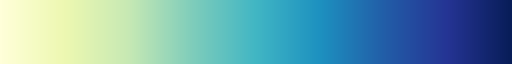

In [469]:
cmap = plt.colormaps["YlGnBu"]
cmap

The colormap as $256$ color values, show above as a gradient.

In [441]:
cmap.N

256

We can take any number in $[0, 1]$ and get the corresponding color code for it.

Here we see the results of converting $.5$, showing the result as an indexed series for demonstration purposes.

In [442]:
cmap_demo = pd.Series(cmap(.5), index=['r','g','b','a'])
cmap_demo

r    0.252687
g    0.711449
b    0.768381
a    1.000000
dtype: float64

Often, we will convert these values to $[0, 255]$.

In [443]:
(cmap_demo * 255).astype(int)

r     64
g    181
b    195
a    255
dtype: int64

Or, we convert to hexadecimal, the format that color codes are often expressed.

In [444]:
(cmap_demo * 255).astype(int).map(hex)

r    0x40
g    0xb5
b    0xc3
a    0xff
dtype: str

Now, we convert the dataframe to RGBA values.

In [445]:
flight_wide_scaled_mapped = flight_wide_scaled.map(cmap)
flight_wide_scaled_mapped

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,"(0.8633756247597079, 0.946482122260669, 0.6993...","(0.9911418685121107, 0.996555171088043, 0.8312...","(1.0, 1.0, 0.8509803921568627, 1.0)","(1.0, 1.0, 0.8509803921568627, 1.0)","(0.872725874663591, 0.9501730103806229, 0.6985...","(0.914801999231065, 0.9667820069204152, 0.6952...","(0.9623529411764706, 0.985359477124183, 0.7673...","(0.9490657439446367, 0.9801922337562476, 0.737...","(0.9534948096885814, 0.9819146482122261, 0.747...","(0.8961014994232988, 0.9594002306805075, 0.696...","(0.9534948096885814, 0.9819146482122261, 0.747...","(0.9357785467128028, 0.9750249903883121, 0.708..."
February,"(0.6275893886966551, 0.8543021914648212, 0.720...","(0.8259746251441753, 0.9317185697808535, 0.702...","(0.9490657439446367, 0.9801922337562476, 0.737...","(0.9288273740868896, 0.972318339100346, 0.6941...","(0.872725874663591, 0.9501730103806229, 0.6985...","(1.0, 1.0, 0.8509803921568627, 1.0)","(1.0, 1.0, 0.8509803921568627, 1.0)","(0.9778546712802768, 0.9913879277201076, 0.801...","(1.0, 1.0, 0.8509803921568627, 1.0)","(0.9778546712802768, 0.9913879277201076, 0.801...","(1.0, 1.0, 0.8509803921568627, 1.0)","(0.9977854671280277, 0.9991387927720108, 0.846..."
March,"(0.11534025374855825, 0.552156862745098, 0.745...","(0.2892272202998847, 0.7264590542099193, 0.763...","(0.12867358708189156, 0.5839907727797001, 0.75...","(0.6453056516724337, 0.8611918492887352, 0.719...","(0.1331026528258362, 0.5885428681276432, 0.755...","(0.4265282583621684, 0.7773933102652826, 0.743...","(0.7604613610149944, 0.9059746251441754, 0.707...","(0.618731257208766, 0.8508573625528644, 0.7215...","(0.6010149942329873, 0.8439677047289504, 0.723...","(0.7427450980392157, 0.8990849673202614, 0.709...","(0.6807381776239908, 0.8749711649365628, 0.715...","(0.9288273740868896, 0.972318339100346, 0.6941..."
April,"(0.17739331026528254, 0.6340638216070742, 0.76...","(0.4951787773933103, 0.8028604382929643, 0.733...","(0.592156862745098, 0.8405228758169935, 0.7241...","(0.9101268742791234, 0.9649365628604383, 0.695...","(0.14196078431372547, 0.5976470588235294, 0.75...","(0.5744405997693195, 0.8336332179930797, 0.725...","(0.7250288350634372, 0.8921953094963475, 0.711...","(0.6807381776239908, 0.8749711649365628, 0.715...","(0.7073125720876586, 0.8853056516724337, 0.712...","(0.8493502499038832, 0.9409457900807382, 0.700...","(0.7838985005767013, 0.9151095732410611, 0.705...","(0.654163783160323, 0.864636678200692, 0.71815..."
May,"(0.4799231064975011, 0.797201076509035, 0.7359...","(0.8446751249519415, 0.9391003460207612, 0.700...","(0.2526874279123414, 0.7114494425221068, 0.768...","(0.8774009996155325, 0.9520184544405997, 0.698...","(0.21725490196078429, 0.6750326797385621, 0.76...","(0.4417839292579777, 0.7830526720492119, 0.741...","(0.7073125720876586, 0.8853056516724337, 0.712...","(0.6010149942329873, 0.8439677047289504, 0.723...","(0.6098731257208766, 0.8474125336409073, 0.722...","(0.7338869665513265, 0.8956401384083045, 0.710...","(0.5301499423298732, 0.8164090734332949, 0.730...","(0.5478662053056518, 0.8232987312572089, 0.728..."
June,"(0.12641291810841981, 0.43921568627451, 0.6920...","(0.11410995770857363, 0.5647058823529412, 0.75...","(0.12867358708189156, 0.5839907727797001, 0.75...","(0.11964628988850443, 0.508235294117647, 0.724...","(0.12333717800845828, 0.47058823529411764, 0.7...","(0.12026143790849673, 0.5019607843137255, 0.72...","(0.11410995770857363, 0.5647058823529412, 0.75...","(0.1294886582083814, 0.40784313725490196, 0.67...","(0.1301038062283737, 0.40156862745098043, 0.67...","(0.11657054978854285, 0.5396078431372551, 0.73...","(0.14196078431372547, 0.5976470588235294, 0.75...","(0.11410995770857363, 0.5647058823529412, 0.75..."
July,"(0.03137254901960784, 0.11372549019607843, 0.3...","(0.03137254901960784, 0.11372549019607843, 0.3...","(0.03137254901960784, 0.11372549019607843, 0.3...","(0.1409919261822376, 0.26140715109573254, 0.60...","(0.

Convert the RGB tuples into HTML entities.

In [446]:
(
    flight_wide_scaled_mapped
        .unstack()
        .apply(pd.Series)[[0,1,2]]
        .multiply(255)
        .astype(int)
        .apply(lambda x: f"#{x[0]:02x}{x[1]:02x}{x[2]:02x}", axis=1)
        .unstack()
        .T
        .style.map(lambda c: f'background-color: {c}')
)

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,#dcf1b2,#fcfed3,#ffffd9,#ffffd9,#def2b2,#e9f6b1,#f5fbc3,#f2f9bc,#f3fabe,#e4f4b1,#f3fabe,#eef8b4
February,#a0d9b7,#d2edb3,#f2f9bc,#ecf7b1,#def2b2,#ffffd9,#ffffd9,#f9fccc,#ffffd9,#f9fccc,#ffffd9,#fefed7
March,#1d8cbe,#49b9c2,#2094c0,#a4dbb7,#2196c0,#6cc6bd,#c1e7b4,#9dd8b8,#99d7b8,#bde5b4,#addfb6,#ecf7b1
April,#2da1c1,#7eccbb,#97d6b8,#e8f6b1,#2498c0,#92d4b9,#b8e3b5,#addfb6,#b4e1b5,#d8efb2,#c7e9b3,#a6dcb7
May,#7acbbb,#d7efb2,#40b5c3,#dff2b2,#37acc2,#70c7bd,#b4e1b5,#99d7b8,#9bd8b8,#bbe4b5,#87d0ba,#8bd1b9
June,#2070b0,#1d90bf,#2094c0,#1e81b8,#1f78b4,#1e80b8,#1d90bf,#2168ac,#2166ab,#1d89bc,#2498c0,#1d90bf
July,#081d58,#081d58,#081d58,#23429a,#1c2c81,#081d58,#081d58,#081d58,#0a1f5d,#182979,#12256e,#081d58
August,#081d58,#081d58,#081d58,#081d58,#081d58,#1a2b7d,#243594,#142772,#081d58,#081d58,#081d58,#172978
September,#2166ab,#2251a1,#2069ad,#36aac2,#1e92c0,#1d91c0,#2397c0,#269ac1,#1e92c0,#49b9c2,#30a5c2,#3eb3c3


## Using Matplotlib

At its core a heatmap is just an **array drawn as an image**. Matplotlib's `plt.imshow()` does exactly that: hand it a 2-D array and it colors each entry. Let's build one by hand so the mechanism &mdash; array in, color grid out &mdash; is completely transparent.


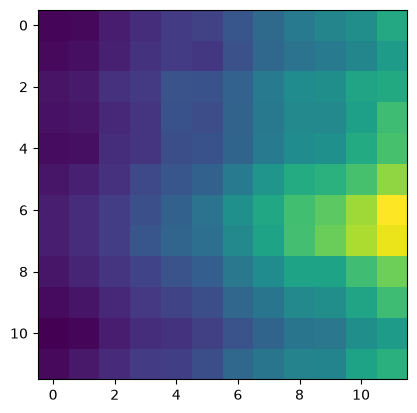

In [447]:
plt.imshow(flight_wide)
plt.show()

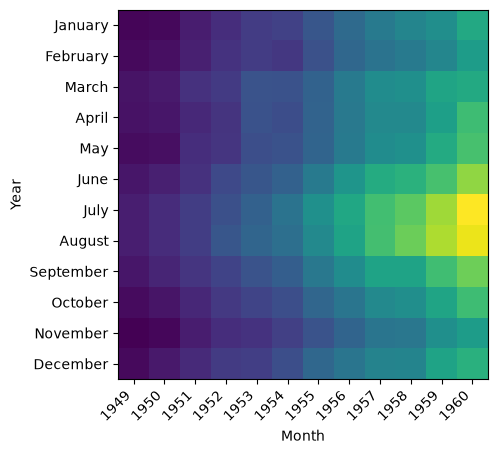

In [455]:
plt.imshow(flight_wide)
plt.xticks(range(len(flight_wide.columns)), labels=flight_wide.columns, rotation=45, ha='right')
plt.yticks(range(len(flight_wide.index)), labels=flight_wide.index)
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

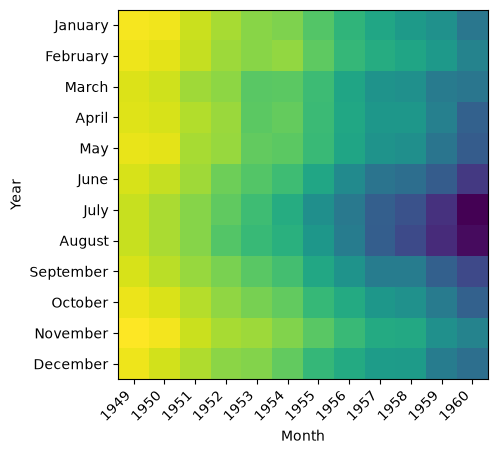

In [457]:
plt.imshow(flight_wide, cmap="viridis_r")
plt.xticks(range(len(flight_wide.columns)), labels=flight_wide.columns, rotation=45, ha='right')
plt.yticks(range(len(flight_wide.index)), labels=flight_wide.index)
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

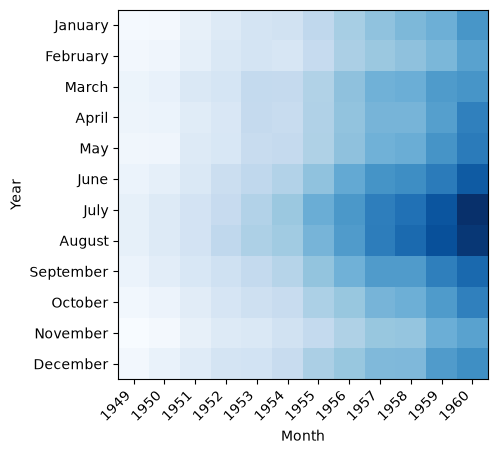

In [462]:
plt.imshow(flight_wide, cmap="Blues")
plt.xticks(range(len(flight_wide.columns)), labels=flight_wide.columns, rotation=45, ha='right')
plt.yticks(range(len(flight_wide.index)), labels=flight_wide.index)
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

## Using Seaborn

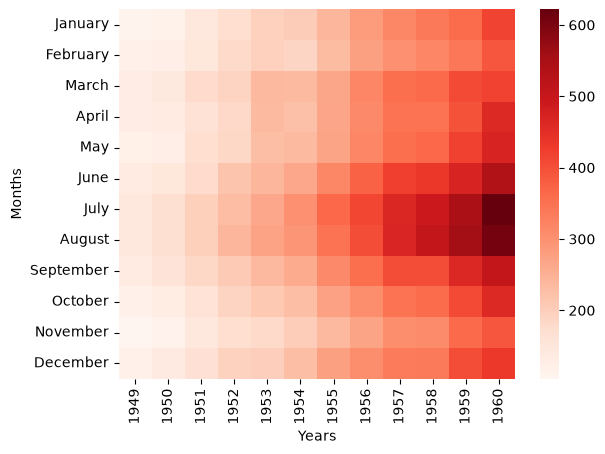

In [464]:
sns.heatmap(flight_wide, cmap='Reds')
plt.show()

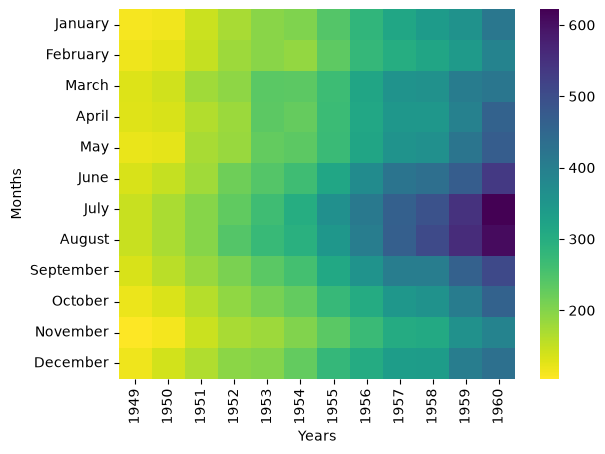

In [385]:
sns.heatmap(flight_wide, cmap='viridis_r')
plt.show()

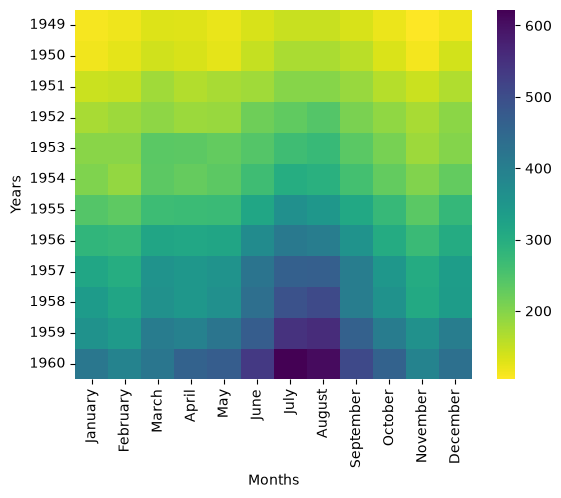

In [386]:
sns.heatmap(flight_wide.T, cmap='viridis_r')
plt.show()

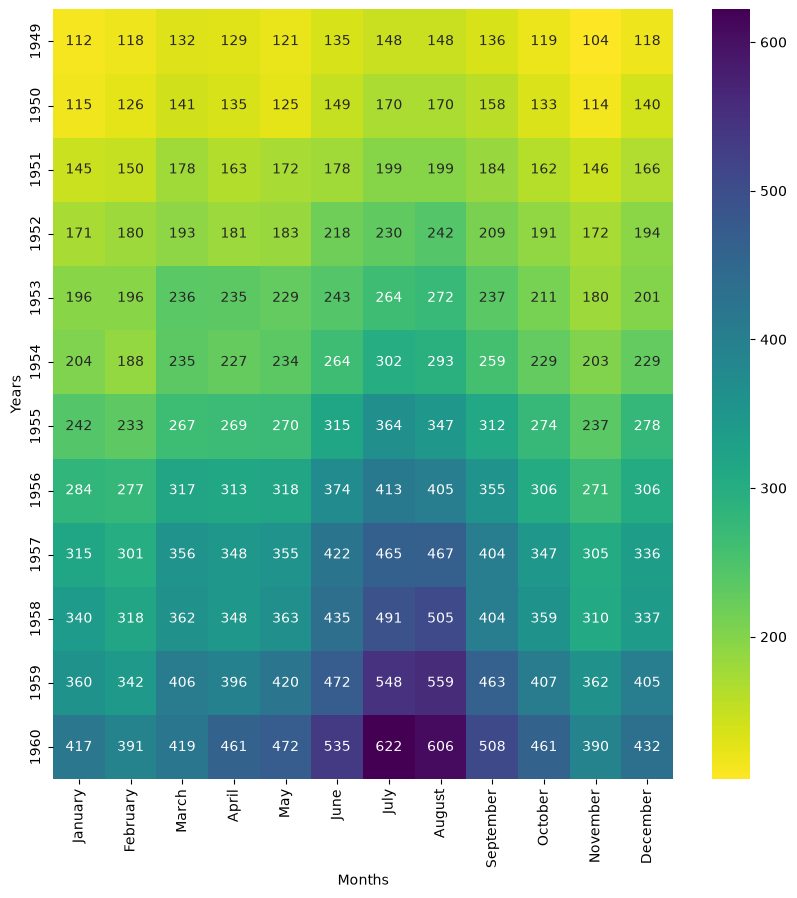

In [393]:
plt.figure(figsize=(10,10))
sns.heatmap(flight_wide.T, annot=True, fmt='d', cmap='viridis_r')
plt.show()

## Using Pandas

Because a heatmap is basically a colored-in wide-form table, Pandas let's you style a dataframe as a heatmap with `.style.background_gradient`.

In [396]:
flight_wide.style.background_gradient() # The gradient goes along axis=0 by default

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
June,135,149,178,218,243,264,315,374,422,435,472,535
July,148,170,199,230,264,302,364,413,465,491,548,622
August,148,170,199,242,272,293,347,405,467,505,559,606
September,136,158,184,209,237,259,312,355,404,404,463,508


In [397]:
flight_wide.style.background_gradient(axis=1)

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
June,135,149,178,218,243,264,315,374,422,435,472,535
July,148,170,199,230,264,302,364,413,465,491,548,622
August,148,170,199,242,272,293,347,405,467,505,559,606
September,136,158,184,209,237,259,312,355,404,404,463,508


In [398]:
flight_wide.style.background_gradient(axis=None)

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
June,135,149,178,218,243,264,315,374,422,435,472,535
July,148,170,199,230,264,302,364,413,465,491,548,622
August,148,170,199,242,272,293,347,405,467,505,559,606
September,136,158,184,209,237,259,312,355,404,404,463,508


In [399]:
flight_wide.style.background_gradient(axis=None, vmin=0, vmax=1000)

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
June,135,149,178,218,243,264,315,374,422,435,472,535
July,148,170,199,230,264,302,364,413,465,491,548,622
August,148,170,199,242,272,293,347,405,467,505,559,606
September,136,158,184,209,237,259,312,355,404,404,463,508


In [400]:
flight_wide.style.background_gradient(axis=None, vmin=0, vmax=1000)

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
June,135,149,178,218,243,264,315,374,422,435,472,535
July,148,170,199,230,264,302,364,413,465,491,548,622
August,148,170,199,242,272,293,347,405,467,505,559,606
September,136,158,184,209,237,259,312,355,404,404,463,508


In [401]:
flight_wide.style.background_gradient(axis=None, vmin=0, vmax=1000, cmap='YlGnBu')

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
June,135,149,178,218,243,264,315,374,422,435,472,535
July,148,170,199,230,264,302,364,413,465,491,548,622
August,148,170,199,242,272,293,347,405,467,505,559,606
September,136,158,184,209,237,259,312,355,404,404,463,508


## Choosing a colormap

There are two families of colormap that are useful for creating and effective heatmap:

1. **Sequential** (`viridis`, `Blues`, `rocket`) &mdash; brightness runs smoothly from low to high. Use these for quantities that go from *little* to *lots*: counts, proportions, magnitudes. Our topic proportions are sequential data.

2. **Diverging** (`coolwarm`, `vlag`, `RdBu`) &mdash; two hues meet at a neutral midpoint. Use these when values have a **meaningful center** (like $0$ for a correlation, or a baseline you deviate from). Set that midpoint with `center=0` so the neutral color lands exactly there.

> [!NOTE]
>
> Normalization does not have to be linear. When most values are tiny and a few are large &mdash; exactly the case for our topic matrix &mdash; a linear scale paints almost everything the same color. A **logarithmic** normalization, $t \propto \log v$, spreads the small values apart so hidden structure becomes visible. We use one below.


> [!CAUTION]
>
> Color is a persuasive channel, so a heatmap can mislead. The wrong `vmin`/`vmax` can hide real variation or manufacture false contrast, and a *rainbow* colormap (like `jet`) creates edges where the data is smooth. Prefer perceptually uniform maps such as `viridis`, and be honest about your normalization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### The dataset: an Austen&ndash;Melville topic matrix

Our data comes from a **topic model** fit to a corpus that mixes the novels of **Jane Austen** and **Herman Melville**. A topic model breaks a collection of texts into a fixed number of latent "topics" &mdash; recurring blends of vocabulary &mdash; and then describes every document as a *mixture* of those topics.

The file `austen-melville-LDA_THETA-40.csv` is the model's **THETA matrix**. It has one row per **chapter** and one column per **topic**:

- `book_id` &mdash; a Project Gutenberg identifier for the book the chapter comes from.
- `chap_id` &mdash; the chapter number within that book.
- `T00`&ndash;`T39` &mdash; forty topic columns. Each value is the **probability** that a randomly chosen word in that chapter belongs to that topic. Because they are a probability distribution, the forty values in each row **sum to $1$**.

Let's load it and look at the shape.

In [2]:
theta = pd.read_csv('austen-melville-LDA_THETA-40.csv')
print(theta.shape)
theta.head()

(1173, 42)


,book_id,chap_id,T00,T01,T02,T03,T04,T05,T06,T07,...,T30,T31,T32,T33,T34,T35,T36,T37,T38,T39
0,105,1,0.000065,0.000065,0.000065,0.000065,0.000065,0.246958,0.000065,0.000065,...,0.000065,0.000065,0.000065,0.000065,0.000065,0.612002,0.000065,0.000065,0.000065,0.000065
1,105,2,0.000089,0.000089,0.000089,0.000089,0.000089,0.694386,0.000089,0.000089,...,0.000089,0.000089,0.000089,0.000089,0.000089,0.218228,0.000089,0.000089,0.000089,0.000089
2,105,3,0.000060,0.000060,0.000060,0.000060,0.000060,0.115819,0.000060,0.000060,...,0.000060,0.000060,0.000060,0.000060,0.000060,0.486383,0.000060,0.000060,0.040438,0.000060
3,105,4,0.000089,0.000089,0.000089,0.000089,0.034618,0.769699,0.000089,0.000089,...,0.000089,0.000089,0.000089,0.000089,0.000089,0.170896,0.000089,0.000089,0.000089,0.000089
4,105,5,0.000059,0.000059,0.000059,0.000059,0.000059,0.197815,0.000059,0.000059,...,0.000059,0.000059,0.000059,0.000059,0.000059,0.616535,0.000059,0.000059,0.000059,0.000059


There are $1{,}173$ chapters and $40$ topic columns. Let's pull out just the topic columns and confirm two things about the numbers: the rows really do sum to $1$, and the individual values are **tiny and lopsided** &mdash; most are near zero, a few are large.

In [3]:
topic_cols = [c for c in theta.columns if c.startswith('T')]

print("number of topics:", len(topic_cols))
print("row sums (should be ~1):", theta[topic_cols].sum(axis=1).head(3).round(4).to_list())
print("min value:", theta[topic_cols].values.min())
print("max value:", theta[topic_cols].values.max())

number of topics: 40
row sums (should be ~1): [1.0, 1.0, 1.0]
min value: 2.073140393069526e-06
max value: 0.9986895161290316


A full $1{,}173 \times 40$ heatmap would be a tall, unreadable smear. To *understand* the mechanism, we take a small, legible slice: the first ten chapters and the first ten topics. That gives us a $10 \times 10$ matrix we can actually inspect cell by cell.

In [4]:
slice_df = theta.loc[:9, topic_cols[:10]]
M = slice_df.to_numpy()
M.shape

(10, 10)

Now the heart of it. `plt.imshow()` takes that array and draws each entry as a colored tile; `plt.colorbar()` adds the legend that maps color back to value. We pass a **sequential** colormap (`viridis`) because topic proportions run from little to lots.

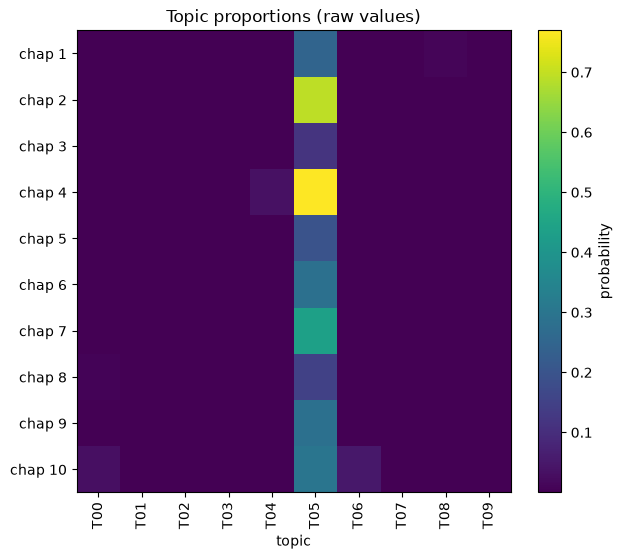

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(M, cmap='viridis', aspect='auto')

ax.set_xticks(range(10), topic_cols[:10], rotation=90)
ax.set_yticks(range(10), [f"chap {i+1}" for i in range(10)])
ax.set_xlabel("topic")
ax.set_title("Topic proportions (raw values)")

fig.colorbar(im, ax=ax, label="probability")
plt.show()

That is a genuine heatmap &mdash; but it is nearly all one color. Because most values are around $0.0001$ and only a couple are large, a **linear** color scale crushes almost every cell to the dark end. The bright cells are real (a topic that dominates a chapter), but the *structure* among the small values is invisible.

This is the normalization problem from the math section. The fix is a **logarithmic** normalization, which spreads the tiny values apart.

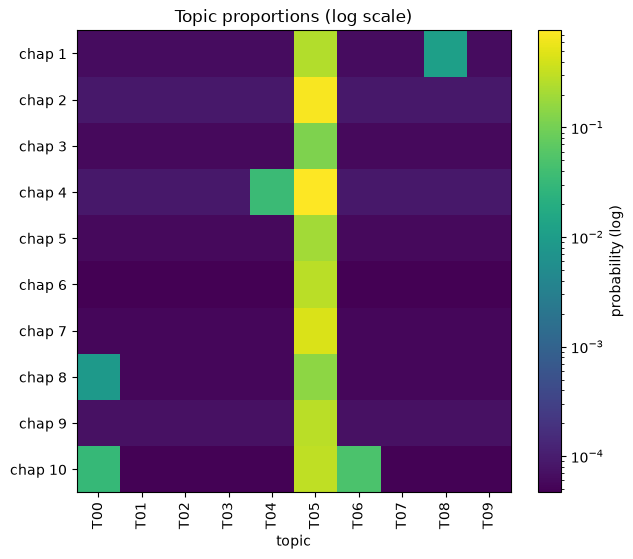

In [6]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(M, cmap='viridis', aspect='auto', norm=LogNorm())

ax.set_xticks(range(10), topic_cols[:10], rotation=90)
ax.set_yticks(range(10), [f"chap {i+1}" for i in range(10)])
ax.set_xlabel("topic")
ax.set_title("Topic proportions (log scale)")

fig.colorbar(im, ax=ax, label="probability (log)")
plt.show()

Same array, same colormap &mdash; but now every cell tells us something. On the log scale you can see which topics a chapter leans on even when the proportions are small. **The array never changed; only the value$\rightarrow$color dictionary did.** That is the whole lesson of normalization.

### A more readable matrix: books &times; topics

Per-chapter rows are noisy and there are far too many of them. A much cleaner view comes from **aggregating**: average each topic's proportion over all the chapters in a book. That collapses $1{,}173$ chapters into $19$ books &mdash; a compact **books &times; topics** matrix that is very readable and, as we'll see, tells a story.

First, a lookup so the rows carry titles and authors instead of bare Gutenberg IDs.

In [7]:
book_info = {
    105:  ("Persuasion",           "Austen"),
    121:  ("Northanger Abbey",     "Austen"),
    141:  ("Mansfield Park",       "Austen"),
    158:  ("Emma",                 "Austen"),
    161:  ("Sense and Sensibility","Austen"),
    946:  ("Lady Susan",           "Austen"),
    1212: ("Love and Friendship",  "Austen"),
    1342: ("Pride and Prejudice",  "Austen"),
    1900: ("Redburn",              "Melville"),
    2701: ("Moby-Dick",            "Melville"),
    4045: ("Omoo",                 "Melville"),
    8118: ("The Piazza Tales",     "Melville"),
    10712:("Israel Potter",        "Melville"),
    13720:("White-Jacket",         "Melville"),
    13721:("Typee",                "Melville"),
    15422:("Bartleby",             "Melville"),
    15859:("Battle-Pieces",        "Melville"),
    21816:("The Confidence-Man",   "Melville"),
    34970:("Mardi",                "Melville"),
}

titles  = {bid: t for bid, (t, a) in book_info.items()}
authors = {bid: a for bid, (t, a) in book_info.items()}

Now average the topic proportions within each book, and label the rows.

In [8]:
book_topics = theta.groupby('book_id')[topic_cols].mean()
book_topics.index = [f"{titles[b]} ({authors[b]})" for b in book_topics.index]
book_topics = book_topics.sort_index()
book_topics.shape

(19, 40)

That is our clean matrix: $19$ books down the side, $40$ topics across the top, each cell the average share of that topic in that book. Now we can hand it to a real library.

## Variations and refinements

A few knobs decide whether a heatmap reads well:

- **Colormap.** Match it to the data. Use a **sequential** map (`viridis`, `rocket`, `Blues`) for quantities that run from low to high, like our proportions. Use a **diverging** map with `center=0` (`coolwarm`, `vlag`) only when the data has a meaningful midpoint, such as a correlation matrix. Avoid rainbow maps like `jet`.
- **Normalization.** `vmin` and `vmax` fix the color scale; set them to compare two heatmaps fairly, or to clip distracting outliers. When values span orders of magnitude and cluster near zero &mdash; our exact situation &mdash; reach for `LogNorm` so the small values are not all painted the same color.
- **Aspect and orientation.** A very long, thin matrix is hard to read. **Transpose** it (`book_topics.T`) to swap the axes, or tune `figsize` so the cells are close to square. A readable heatmap usually has cells that are neither slivers nor giant blocks.
- **Aggregate to reduce clutter.** We turned $1{,}173$ noisy chapter rows into $19$ clean book rows by averaging. Summarizing before you plot is often the difference between an unreadable smear and a heatmap that tells a story.

The core design decision, though, is always the same one from the math section: **how you map value to color.** Get the colormap and the normalization right, and the heatmap does the rest.

:::{note}
We averaged chapters up to books to make the matrix legible. What would you *lose* by doing that &mdash; and when might the noisy, full $1{,}173 \times 40$ chapter heatmap reveal something the aggregated view hides?
:::